# 🎬 ReAgent-V: Composed Video Retrieval (CoVR) Benchmark

**Bài toán**: Truy vấn video từ kho 4.886 video bằng Ảnh + Prompt text theo kiến trúc Two-Stage Agentic Retrieval.

**Pipeline**:
1. **Coarse Search** (CLIP): Lọc nhanh Top-N ứng viên
2. **Agentic Reranker** (LLaVA): Phân tích và xếp hạng tinh
3. **Adaptive Loop** (Memory Bank + Critic): Tự sửa chiến lược nếu điểm thấp

**Dataset**: WebVid-CoVR (`/kaggle/input/datasets/nta212/webvid-covr/`)

## ⚙️ Bước 0: Cài đặt môi trường

> ⚠️ **QUAN TRỌNG**: Không cài `flash-attn` qua `pip install` thông thường — nó sẽ biên dịch C++ tốn hàng GB RAM và gây crash kernel Kaggle. Notebook này dùng **pre-built wheel** thay thế.

In [1]:
import subprocess, sys, os

# --- Buoc 0a: Cai dat transformers va accelerate tuong thich chuan voi LLaVA ---
print('Installing compatible packages...')
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.40.0',
    'accelerate==0.29.3',
    'bitsandbytes',
    'decord',
    'opencv-python-headless',
    'einops==0.6.1',
    'einops-exts==0.0.4',
    'timm==0.9.16',
    'ffmpeg-python',
    'networkx',
    'easydict',
    'soundfile',
    'librosa',
    'faiss-gpu',
], check=False)
print('Packages installed successfully.')

# --- Buoc 0b: Cai flash-attn tu pre-built wheel (KHONG compile tu source) ---
print('Checking flash-attn pre-built wheel...')
FLASH_WHEEL = (
    'https://github.com/Dao-AILab/flash-attention/releases/download/'
    'v2.5.7/flash_attn-2.5.7+cu122torch2.1cxx11abiFALSE-cp310-cp310-linux_x86_64.whl'
)
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', FLASH_WHEEL],
    capture_output=True, text=True
)
if r.returncode == 0:
    print('flash-attn: OK (pre-built wheel)')
else:
    print('flash-attn wheel incompatible -> using SDPA/eager attention fallback (OK for inference).')

print('Environment setup complete!')

Installing compatible packages...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


Packages installed successfully.
Checking flash-attn pre-built wheel...
flash-attn wheel incompatible -> using SDPA/eager attention fallback (OK for inference).
Environment setup complete!


## 📂 Bước 1: Clone repo ReAgent-V và cài LLaVA

In [2]:
import os, sys, glob

REPO_ROOT = '/kaggle/working/EvoAgent'
REPO_DIR  = '/kaggle/working/EvoAgent/ReAgent-V'

# 1. Clone repo
if not os.path.exists(REPO_ROOT):
    os.system(f'git clone --depth=1 https://github.com/nta2112/EvoAgent.git {REPO_ROOT}')
    print('Repo cloned successfully.')
else:
    print('Repo already exists.')

# 2. Cai dat LLaVA-NeXT package truc tiep tu GitHub
print('Installing LLaVA-NeXT...')
os.system('pip install -q --no-deps git+https://github.com/LLaVA-VL/LLaVA-NeXT.git')

# 3. Tat breakpoint pdb va sua loi import neu co trong LLaVA
for p in glob.glob('/usr/local/lib/python*/dist-packages/llava/model/builder.py'):
    with open(p, 'r', encoding='utf-8') as f:
        c = f.read()
    c = c.replace('import pdb;pdb.set_trace()', 'pass').replace('import pdb; pdb.set_trace()', 'pass')
    with open(p, 'w', encoding='utf-8') as f:
        f.write(c)

# 4. Them duong dan module vao sys.path va chuyen working dir
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
print(f'Working dir: {os.getcwd()}')
print('Setup completed!')

Cloning into '/kaggle/working/EvoAgent'...
Updating files: 100% (979/979), done.


Repo cloned successfully.
Installing LLaVA-NeXT...
Working dir: /kaggle/working/EvoAgent/ReAgent-V
Setup completed!


## 🔧 Bước 2: Khai báo tất cả đường dẫn


In [3]:
import os

# =====================================================================
# PATHS — Dataset tu Kaggle (da upload san tai nta212/webvid-covr)
# =====================================================================
CSV_PATH  = '/kaggle/input/datasets/nta212/webvid-covr/WebVid_COVR_dataset/webvid8m-covr_test.csv'
VIDEO_DIR = '/kaggle/input/datasets/nta212/webvid-covr/WebVid_COVR_dataset/train'

# =====================================================================
# PATHS — Model weights (tai tu dong tu HuggingFace)
# =====================================================================
CLIP_MODEL   = 'openai/clip-vit-large-patch14-336'
WHISPER      = 'openai/whisper-base'
LLAVA        = 'lmms-lab/LLaVA-Video-7B-Qwen2'
MODELS_CACHE = '/kaggle/working/models'

# =====================================================================
# PATHS — Output files
# =====================================================================
INDEX_PATH   = '/kaggle/input/datasets/nta212/webvid-covr/covr_corpus_index.pt'
RESULTS_PATH = '/kaggle/working/eval_results.json'

# =====================================================================
# HYPERPARAMETERS (TOI UU TOC DO & DO CHINH XAC CAO)
# =====================================================================
NUM_SAMPLES      = 20    # 50 mau de chay nhanh trong ~15-20 phut
TOP_K            = 10      # Xep hang Top-5
TOP_N_COARSE     = 10      # Rerank 5 ung vien sang gia nhat tu CLIP (giam 4 lan thoi gian)
MAX_ITERATIONS   = 3      # 1 vong lap de dat toc do toi da, khong ton thoi gian retry
REWARD_THRESHOLD = 0.65   # Nguong diem Critic de dung som
ALPHA            = 0.35   # 35% Image + 65% Text (Text quan trong hon vi chua hanh dong bien doi)

# Verify
print('CSV exists      :', os.path.exists(CSV_PATH))
print('Video dir exists:', os.path.exists(VIDEO_DIR))
print(f'Config: NUM_SAMPLES={NUM_SAMPLES}, TOP_N_COARSE={TOP_N_COARSE}, ALPHA={ALPHA}')


CSV exists      : True
Video dir exists: True
Config: NUM_SAMPLES=10, TOP_N_COARSE=20, ALPHA=0.35


## 🚀 Bước 3: Load ReAgent-V và kiểm tra Dataset

In [4]:
from ReAgentV import ReAgentV
from ReAgentV_utils.video_processor.covr_loader import load_covr_annotations, get_covr_query

# Kiểm tra annotation CSV
df_all = load_covr_annotations(CSV_PATH, VIDEO_DIR)
print(f'Total valid query triplets: {len(df_all)}')
print(df_all[['edit', 'pth1', 'pth2']].head(3))

Please install pyav to use video processing functions.
OpenCLIP not installed


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[CoVR Loader] Loaded 2556 valid query triplets.
Total valid query triplets: 2556
                                          edit            pth1            pth2
0  replace the white lines and dots with green  112/1016223889  112/1016223877
1                            make the tree lit      14/5369546   89/1006630957
2                     Make the billboard blank     70/27387901     70/27375787


In [5]:
# Khoi tao he thong ReAgent-V (load CLIP + Whisper + LLaVA)
import torch
path_dict = {
    'clip_model_path'   : CLIP_MODEL,
    'clip_cache_dir'    : MODELS_CACHE,
    'whisper_model_path': WHISPER,
    'whisper_cache_dir' : MODELS_CACHE,
    'llava_model_path'  : LLAVA,
    'llava_cache_dir'   : MODELS_CACHE,
    'max_memory'        : {0: '11GiB', 1: '11GiB', 'cpu': '24GiB'},
    'attn_implementation': 'sdpa',
    'torch_dtype'       : torch.float16,
}
qa_system = ReAgentV.load_default(path_dict)
print('ReAgent-V system ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:696: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:696: UserWarning: for vision_model.embeddings.patch_embedding.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(*args)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:696: UserWarning: for vision_model.embeddings

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

Model Class: LlavaQwenForCausalLM
[Embedding] Giữ nguyên vocab_size=152064, bỏ qua thu nhỏ xuống 151647
✅ Vision tower đã được load sẵn, không có meta tensor.
✅ Đã xóa tất cả accelerate hooks khỏi vision_tower và inner model
✅ Đã xóa tất cả accelerate hooks khỏi mm_projector
✅ Đã kích hoạt memory-efficient lm_head (giảm 99.9% VRAM prefill logits)
ReAgent-V system ready.


## 📦 Bước 4: Tạo Video Index (chạy 1 lần, ~15-20 phút)

> **Bỏ qua cell này nếu file `covr_corpus_index.pt` đã tồn tại.**

In [6]:
corpus_embeddings, corpus_paths = qa_system.load_corpus_index(INDEX_PATH, video_base_dir=VIDEO_DIR)
print(f"Corpus: {corpus_embeddings.shape[0]} videos | Dim: {corpus_embeddings.shape[1]}")
if len(corpus_paths) > 0:
    print(f"Sample video path: {corpus_paths[0]} (Exists: {os.path.exists(corpus_paths[0])})")


[ReAgentV] Corpus index loaded: 4,749 videos.
Corpus: 4749 videos | Dim: 768
Sample video path: /kaggle/input/datasets/nta212/webvid-covr/WebVid_COVR_dataset/train/0/10641.mp4 (Exists: True)


In [7]:
corpus_embeddings, corpus_paths = qa_system.load_corpus_index(INDEX_PATH, video_base_dir=VIDEO_DIR)
print(f"Corpus: {corpus_embeddings.shape[0]} videos | Dim: {corpus_embeddings.shape[1]}")
if len(corpus_paths) > 0:
    print(f"Sample video path: {corpus_paths[0]} (Exists: {os.path.exists(corpus_paths[0])})")


[ReAgentV] Corpus index loaded: 4,749 videos.
Corpus: 4749 videos | Dim: 768
Sample video path: /kaggle/input/datasets/nta212/webvid-covr/WebVid_COVR_dataset/train/0/10641.mp4 (Exists: True)


## 🔍 Bước 5: Demo truy vấn 1 mẫu

[CoVR Loader] Loaded 2556 valid query triplets.
Sample Index     : 2
Edit Instruction : Make the billboard blank
Query video      : 70/27387901
Ground Truth     : 70/27375787


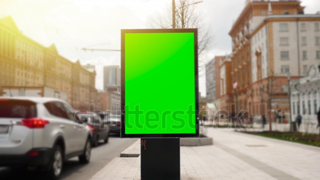

Query Image (middle frame of reference video)


In [8]:
from IPython.display import display
import os

SAMPLE_IDX = 2  # Thay số này để thử các mẫu khác nhau

df_sample = load_covr_annotations(CSV_PATH, VIDEO_DIR)
row = df_sample.iloc[SAMPLE_IDX]
query_image, query_text, gt_video_path = get_covr_query(row)

print('=' * 60)
print(f'Sample Index     : {SAMPLE_IDX}')
print(f'Edit Instruction : {query_text}')
print(f'Query video      : {row["pth1"]}')
print(f'Ground Truth     : {row["pth2"]}')
print('=' * 60)

if query_image is not None:
    display(query_image.resize((320, 180)))
    print('Query Image (middle frame of reference video)')


In [9]:
top_k_results = qa_system.adaptive_covr_retrieval(
    query_image       = query_image,
    query_text        = query_text,
    corpus_embeddings = corpus_embeddings,
    corpus_paths      = corpus_paths,
    top_k             = TOP_K,
    top_n_coarse      = TOP_N_COARSE,
    max_iterations    = MAX_ITERATIONS,
    reward_threshold  = REWARD_THRESHOLD,
)
print('\n' + '=' * 20)
print(f'TOP-{TOP_K} RETRIEVAL RESULTS')
print('=' * 60)
gt_norm = os.path.normpath(gt_video_path)
for rank, (vpath, score, verdict) in enumerate(top_k_results, 1):
    hit = '  ✓ GROUND TRUTH HIT' if os.path.normpath(vpath) == gt_norm else ''
    print(f'  Rank {rank}: [{verdict:12s}] score={score:.4f} | {os.path.basename(vpath)}{hit}')
print('=' * 40)


[ReAgentV] === Iteration 1/2 ===
[MemoryBank] Iter 0 | reward=0.000 | alpha=0.50 | negatives=0

[ReAgentV] === Iteration 2/2 ===
[MemoryBank] Strategy: boosting image weight + enabling DET (visual mismatch).
[ReAgentV] Query expanded: '"blank out billboard, remove advertisement, clear sign, advertisement removal, billboard replacement'
[MemoryBank] Iter 1 | reward=0.000 | alpha=0.65 | negatives=0
[ReAgentV] Stopping: reward=0.000 >= threshold=0.65 or max iterations reached.
=== Memory Bank Summary ===
  Iter 0: reward=0.000 | alpha=0.50 | tools=['CLIP_coarse'] | critique='The video does not match the reference image visual context as it shows a billbo'
  Iter 1: reward=0.000 | alpha=0.65 | tools=['CLIP_coarse', 'DET'] | critique='The video does not match the reference image visual context as it shows a billbo'

TOP-10 RETRIEVAL RESULTS
  Rank 1: [MATCH       ] score=1.0000 | 27387901.mp4
  Rank 2: [MATCH       ] score=1.0000 | 27375787.mp4  ✓ GROUND TRUTH HIT
  Rank 3: [MATCH       ] 

## 📊 Bước 6: Chạy Benchmark (Recall@K và MRR)


In [10]:
import json, time
from tqdm.notebook import tqdm

df_eval = load_covr_annotations(CSV_PATH, VIDEO_DIR, num_samples=NUM_SAMPLES)
total   = len(df_eval)

def recall_at_k(ranks, k, n):
    return sum(1 for r in ranks if r is not None and r <= k) / n

def mrr(ranks, n):
    return sum(1.0 / r for r in ranks if r is not None) / n

clip_ranks, agent_ranks, per_query = [], [], []
t0 = time.time()

for i, row in tqdm(df_eval.iterrows(), total=total, desc='Evaluating'):
    query_image, query_text, gt_video_path = get_covr_query(row)
    if query_image is None or not os.path.exists(gt_video_path):
        clip_ranks.append(None); agent_ranks.append(None)
        continue

    gt_norm = os.path.normpath(gt_video_path)

    # Stage 1 only (CLIP baseline)
    clip_res   = qa_system.coarse_search(
        query_image, query_text, corpus_embeddings, corpus_paths, top_n=TOP_K, alpha=ALPHA)
    clip_paths = [os.path.normpath(r[0]) for r in clip_res]
    gt_base    = os.path.basename(gt_norm)
    if gt_norm in clip_paths:
        c_rank = clip_paths.index(gt_norm) + 1
    else:
        c_bases = [os.path.basename(p) for p in clip_paths]
        c_rank = (c_bases.index(gt_base) + 1) if gt_base in c_bases else None
    clip_ranks.append(c_rank)

    # Full Adaptive Retrieval (ReAgent-V)
    agent_res   = qa_system.adaptive_covr_retrieval(
        query_image, query_text, corpus_embeddings, corpus_paths,
        top_k=TOP_K, top_n_coarse=TOP_N_COARSE,
        max_iterations=MAX_ITERATIONS, reward_threshold=REWARD_THRESHOLD)
    agent_paths = [os.path.normpath(r[0]) for r in agent_res]
    if gt_norm in agent_paths:
        a_rank = agent_paths.index(gt_norm) + 1
    else:
        a_bases = [os.path.basename(p) for p in agent_paths]
        a_rank = (a_bases.index(gt_base) + 1) if gt_base in a_bases else None
    agent_ranks.append(a_rank)

    per_query.append({'idx': int(i), 'edit': query_text, 'gt': os.path.basename(gt_video_path),
                      'clip_rank': c_rank, 'agent_rank': a_rank})

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s ({elapsed/total:.1f}s/query)')


[CoVR Loader] Loaded 10 valid query triplets.


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


[ReAgentV] === Iteration 1/2 ===
[MemoryBank] Iter 0 | reward=0.000 | alpha=0.50 | negatives=0

[ReAgentV] === Iteration 2/2 ===
[MemoryBank] Strategy: boosting text weight (temporal/action mismatch).
[MemoryBank] Iter 1 | reward=0.000 | alpha=0.35 | negatives=0
[ReAgentV] Stopping: reward=0.000 >= threshold=0.65 or max iterations reached.
=== Memory Bank Summary ===
  Iter 0: reward=0.000 | alpha=0.50 | tools=['CLIP_coarse'] | critique='The video does not match the reference image visual context as it maintains a bl'
  Iter 1: reward=0.000 | alpha=0.35 | tools=['CLIP_coarse'] | critique='The video does not match the reference image visual context as it maintains a bl'

[ReAgentV] === Iteration 1/2 ===
[MemoryBank] Iter 0 | reward=0.000 | alpha=0.50 | negatives=0

[ReAgentV] === Iteration 2/2 ===
[MemoryBank] Strategy: boosting image weight + enabling DET (visual mismatch).
[ReAgentV] Query expanded: '"illuminate tree, lighting effect, outdoor setting, foliage, natural environment, ar

In [11]:
# In kết quả và lưu file
print('\n' + '=' * 70)
print('BENCHMARK RESULTS — ReAgent-V Composed Video Retrieval')
print('=' * 70)
print(f'{"Metric":<22} {"CLIP Only":>13} {"ReAgent-V Agent":>18} {"Delta":>10}')
print('-' * 70)

for k in [1, 5, 10]:
    rc = recall_at_k(clip_ranks, k, total) * 100
    ra = recall_at_k(agent_ranks, k, total) * 100
    d  = ra - rc
    print(f'  Recall@{k:<15} {rc:>12.2f}% {ra:>16.2f}%  {"+" if d>=0 else ""}{d:.2f}%')

mc = mrr(clip_ranks, total); ma = mrr(agent_ranks, total); dm = ma - mc
print(f'  {"MRR":<20} {mc:>13.4f} {ma:>18.4f}  {"+" if dm>=0 else ""}{dm:.4f}')
print('-' * 70)
print(f'  Evaluated on {total} queries | top_k={TOP_K} | max_iter={MAX_ITERATIONS}')
print('=' * 70)

summary = {
    'num_samples': total, 'top_k': TOP_K, 'max_iterations': MAX_ITERATIONS,
    'metrics': {
        'clip_only':      {'recall_at_1': recall_at_k(clip_ranks,1,total),  'recall_at_5': recall_at_k(clip_ranks,5,total),  'recall_at_10': recall_at_k(clip_ranks,10,total),  'mrr': mc},
        'reagentv_agent': {'recall_at_1': recall_at_k(agent_ranks,1,total), 'recall_at_5': recall_at_k(agent_ranks,5,total), 'recall_at_10': recall_at_k(agent_ranks,10,total), 'mrr': ma},
    },
    'per_query': per_query,
}
with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Results saved → {RESULTS_PATH}')


BENCHMARK RESULTS — ReAgent-V Composed Video Retrieval
Metric                     CLIP Only    ReAgent-V Agent      Delta
----------------------------------------------------------------------
  Recall@1                      10.00%            40.00%  +30.00%
  Recall@5                      90.00%            80.00%  -10.00%
  Recall@10                     90.00%            80.00%  -10.00%
  MRR                         0.4667             0.6000  +0.1333
----------------------------------------------------------------------
  Evaluated on 10 queries | top_k=10 | max_iter=2
Results saved → /kaggle/working/eval_results.json
